mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.0532000000476838 seconds
All requested packages already installed.
<class 'pandas.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   2025 Rank                       1503 non-null   str    
 1   2024 Rank                       1482 non-null   str    
 2   Institution Name                1503 non-null   str    
 3   Location                        1503 non-null   str    
 4   Location Full                   1503 non-null   str    
 5   Size                            1503 non-null   str    
 6   Academic Reputation             1503 non-null   float64
 7   Employer Reputation             1503 non-null   float64
 8   Faculty Stu

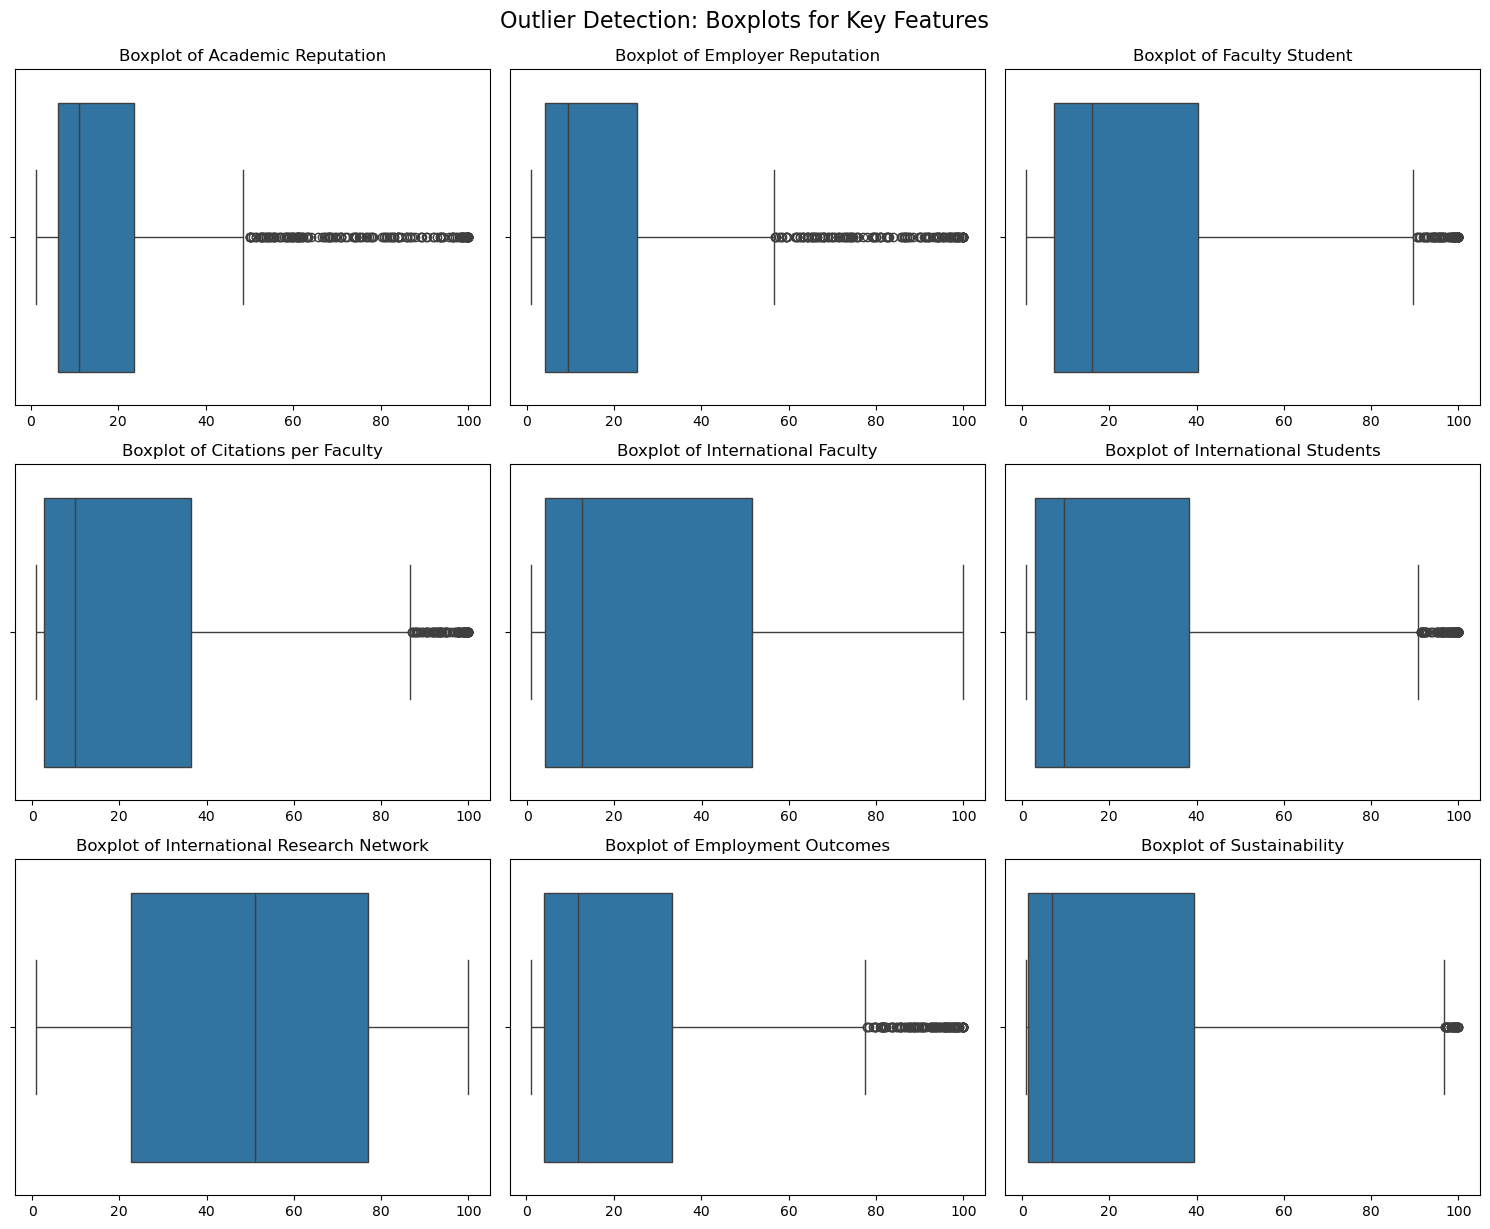

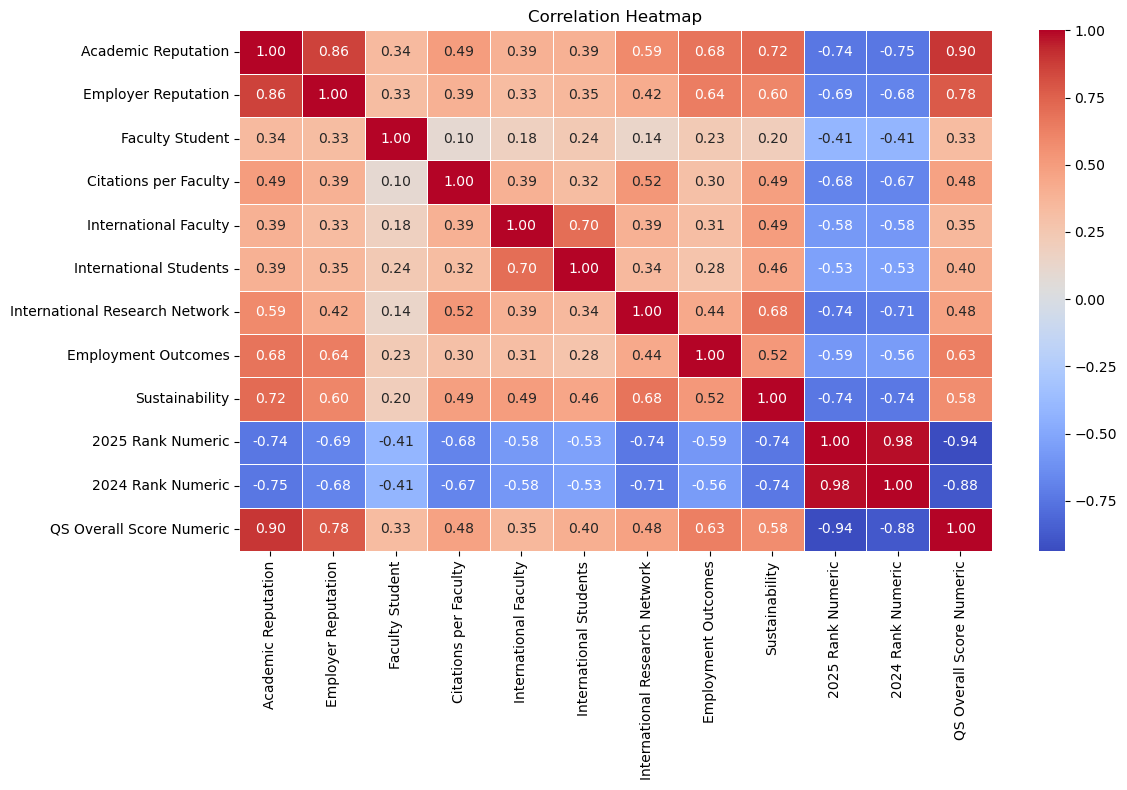

-----------------------------
K-Means Clustering
2. Running the Elbow Method to find the perfect K
3. Training the final AI with K = 3, and mapping the university clusters


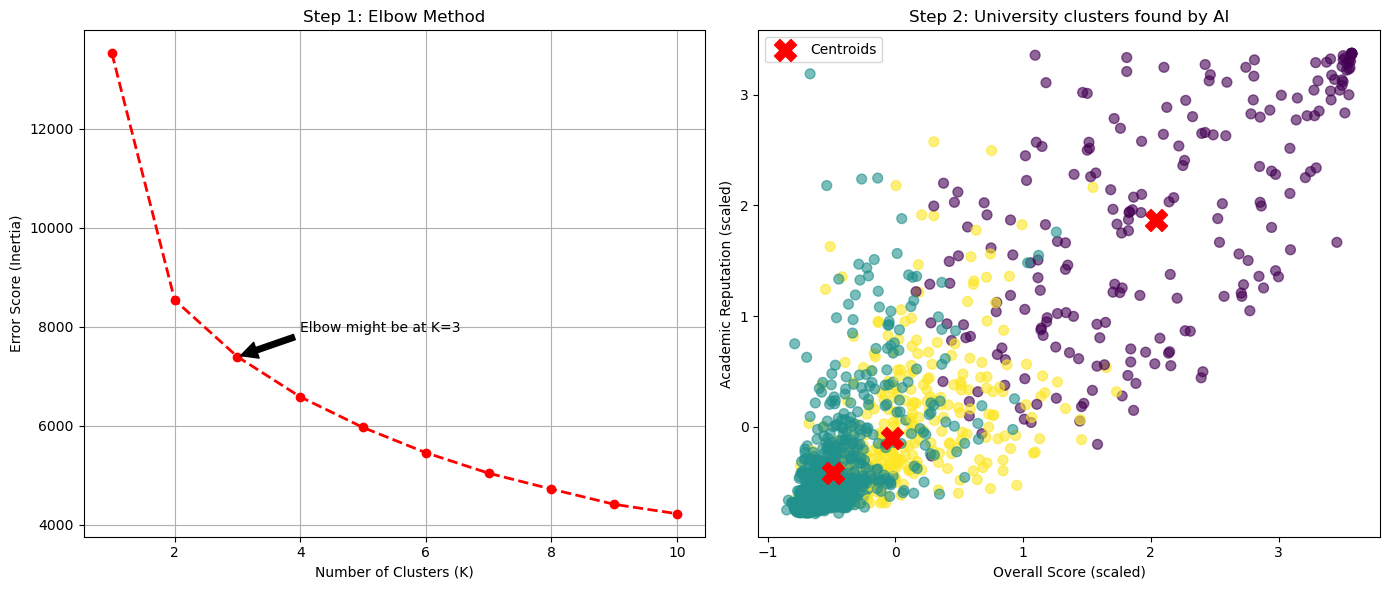

3. Training the final AI with K = 4, and mapping the university clusters


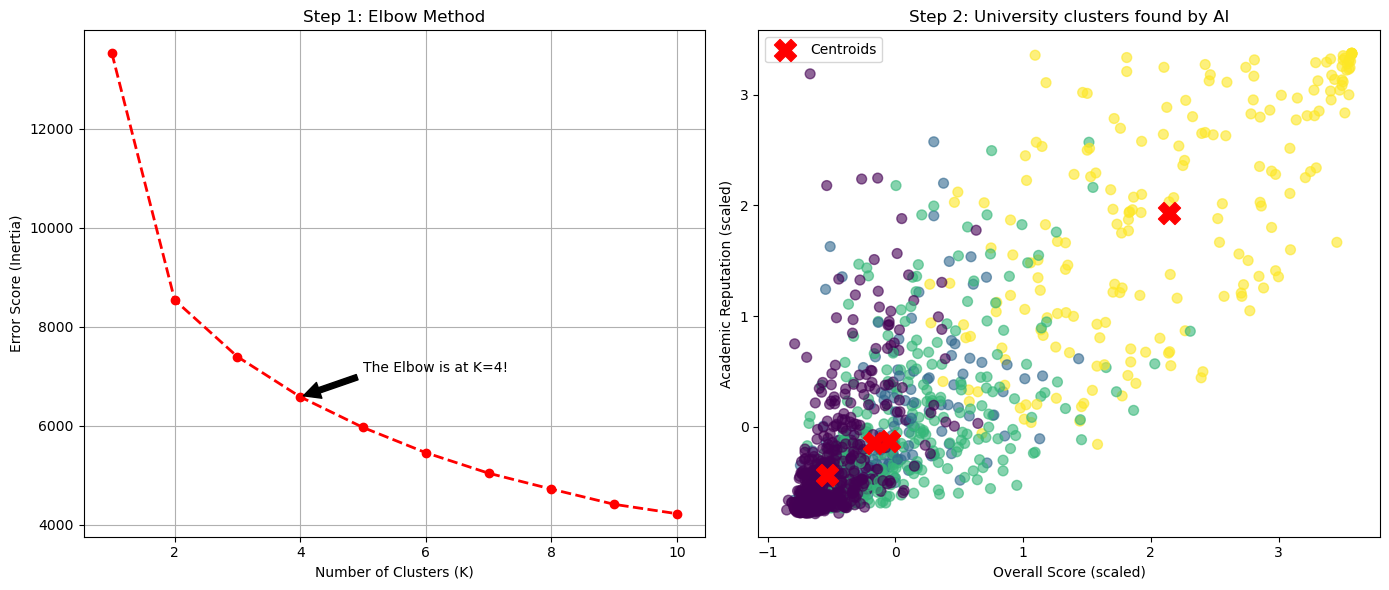


Average feature scores per cluster:
         Academic Reputation  Employer Reputation  Faculty Student  Citations per Faculty  International Faculty  International Students  International Research Network  Employment Outcomes  Sustainability
Cluster                                                                                                                                                                                                      
0                       8.41                 9.50            23.54                   6.51                  11.73                    9.94                           26.42                11.85            4.58
1                      16.51                16.19            29.71                  29.78                  79.96                   69.97                           58.62                21.07           35.01
2                      19.26                16.69            25.32                  35.14                  17.90                   13.10   

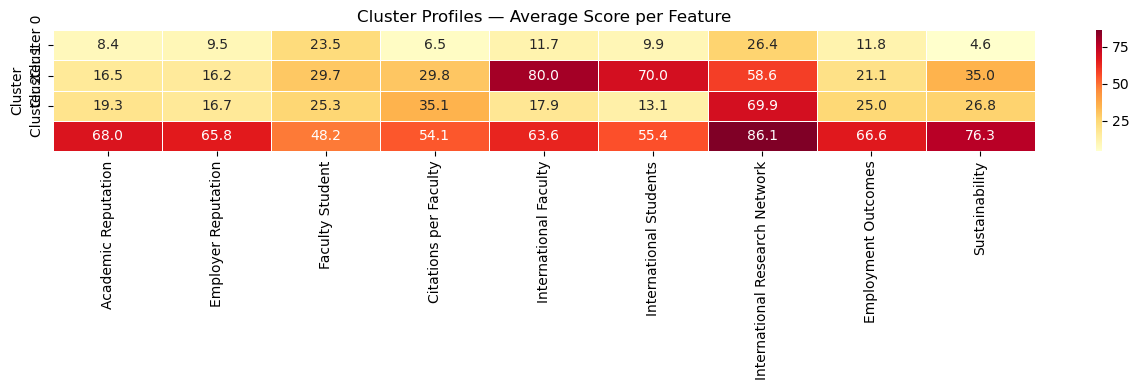

In [2]:
#PHASE 1
!mamba install pandas matplotlib seaborn scikit-learn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


def parse_rank_value(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if text == '-':
        return np.nan

    if '-' in text:
        left, right = text.split('-', 1)
        if left.isdigit() and right.isdigit():
            return int((int(left) + int(right)) // 2)

    if text.endswith('+') and text[:-1].isdigit():
        return int(text[:-1])

    try:
        return int(float(text))
    except ValueError:
        return np.nan


def parse_score_value(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if text == '-':
        return np.nan

    try:
        return round(float(text), 2)
    except ValueError:
        return np.nan

df = pd.read_csv('qs-world-rankings-2025.csv')
print(df.info())
print(f"Count of missing values in each column: \n{df.isna().sum()}\n") 
print(f"Total number of missing values in the dataset: {df.isna().sum().sum()}\n") 

# Parse rank/score into *_Numeric columns; drop the raw string originals.
df['2025 Rank Numeric'] = df['2025 Rank'].apply(parse_rank_value)
df['2024 Rank Numeric'] = df['2024 Rank'].apply(parse_rank_value)
df['QS Overall Score Numeric'] = df['QS Overall Score'].apply(parse_score_value)
df.drop(columns=['2025 Rank', '2024 Rank', 'QS Overall Score'], inplace=True)

print(df.shape) # output: (1503, 16)

# print(df.info()) #General info about the dataset, including data types and non-null counts

# print(f"Count of missing values in each column: \n{df.isna().sum()}\n") 
# print(f"Total number of missing values in the dataset: {df.isna().sum().sum()}\n") 

# median imputation for numeric columns 
numeric_cols = df.select_dtypes(include=[np.number]).columns
new_df = df.copy()
new_df[numeric_cols] = new_df[numeric_cols].fillna(new_df[numeric_cols].median())

# Keep rank columns as whole integers and QS score at 2 decimal places
new_df['2025 Rank Numeric'] = new_df['2025 Rank Numeric'].round().astype('Int64')
new_df['2024 Rank Numeric'] = new_df['2024 Rank Numeric'].round().astype('Int64')
new_df['QS Overall Score Numeric'] = new_df['QS Overall Score Numeric'].round(2)

print(f"Check if there are any missing values left after imputation: {new_df.isna().sum().sum()}")
print(f"New dataset shape after imputation: {new_df.shape}")

# Export Phase-2-ready cleaned CSV
new_df.to_csv('qs-world-rankings-2025-cleaned.csv', index=False)
print("Exported: qs-world-rankings-2025-cleaned.csv")

print(new_df)
#Explore the dataset
print(df.describe())

print(f"Outliers detection using boxplot\n")
cols = ['Academic Reputation',
        'Employer Reputation',
        'Faculty Student',
        'Citations per Faculty',
        'International Faculty',
        'International Students',
        'International Research Network',
        'Employment Outcomes', 'Sustainability']

# Create a single figure with subplots for all boxplots
n_cols = 3  # Number of columns for subplots
n_rows = (len(cols) + n_cols - 1) // n_cols  # Calculate number of rows needed

plt.figure(figsize=(n_cols * 5, n_rows * 4)) # Adjust figure size dynamically

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i + 1) # Create subplot
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel('') # Remove x-label for cleaner look if not needed

plt.tight_layout()
plt.suptitle('Outlier Detection: Boxplots for Key Features', y=1.02, fontsize=16) # Add a super title
plt.show()


# Correlation heatmap (numeric columns only)
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

print(f"-----------------------------")
print(f"K-Means Clustering")

X = new_df[cols].copy()
#print(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
#print(X_scaled)

print("2. Running the Elbow Method to find the perfect K")
error_scores = []

for i in range(1, 11):
    kmeans_tester = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans_tester.fit(X_scaled)
    error_scores.append(kmeans_tester.inertia_)

# Plot the clusters side by side
plt.figure(figsize=(14,6))

# Graph 1 - the elbow
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), error_scores, marker='o', linestyle='--', color='red', linewidth=2)
plt.title('Step 1: Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Error Score (Inertia)')
plt.grid(True)

#K =3
# annotate the elbow (approximate)
plt.annotate('Elbow might be at K=3', xy=(3, error_scores[2]),
             xytext=(4, error_scores[2]+500),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Graph 2: Final Clusters
print("3. Training the final AI with K = 3, and mapping the university clusters")

final_ai = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
university_clusters = final_ai.fit_predict(X_scaled)

# Get the exact coordinates of the centroids
centroids = final_ai.cluster_centers_

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=university_clusters, s=50, alpha=0.6)

# Plot the centroids as giant red X
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=250, label="Centroids")

plt.title("Step 2: University clusters found by AI")
plt.xlabel("Overall Score (scaled)")
plt.ylabel("Academic Reputation (scaled)")
plt.legend()

plt.tight_layout()
plt.show()
#---------------------------------

#plt.figure() so K=4 plot doesn't draw on top of K=3
plt.figure(figsize=(14,6))

# Graph 1 - the elbow
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), error_scores, marker='o', linestyle='--', color='red', linewidth=2)
plt.title('Step 1: Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Error Score (Inertia)')
plt.grid(True)
# K = 4
# annotate the elbow (approximate)
plt.annotate('The Elbow is at K=4!', xy=(4, error_scores[3]), xytext=(5, error_scores[3]+500),
             arrowprops=dict(facecolor='black', shrink=0.05))

# Graph 2: Final Clusters
print("3. Training the final AI with K = 4, and mapping the university clusters")

final_ai = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
university_clusters = final_ai.fit_predict(X_scaled)

# Get the exact coordinates of the centroids
centroids = final_ai.cluster_centers_

plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=university_clusters, s=50, alpha=0.6)

# Plot the centroids as giant red X
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=250, label="Centroids")

plt.title("Step 2: University clusters found by AI")
plt.xlabel("Overall Score (scaled)")
plt.ylabel("Academic Reputation (scaled)")
plt.legend()

plt.tight_layout()
plt.show()

#Explaination for K = 3 
# It presents a more distinct separation between the clusters, 
# with one cluster representing top-tier universities, another representing mid-tier universities, 
# and the third representing lower-tier universities. 
# The centroids are well-positioned to capture the central tendencies of each cluster, 
# making it easier to interpret the results and identify patterns in the data. 
# In contrast, K=4 may create an additional cluster that does not provide meaningful insights or may lead to overfitting, 
# where the model captures noise rather than underlying patterns.
#Overall , K=3 provides a clearer and more interpretable clustering solution for the university data.

# cluster analysis to justify the cluster names
new_df['Cluster'] = university_clusters
cluster_means = new_df.groupby('Cluster')[cols].mean().round(2)
print("\nAverage feature scores per cluster:")
print(cluster_means.to_string())

plt.figure(figsize=(13, 4))
sns.heatmap(cluster_means, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, yticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2'])
plt.title('Cluster Profiles — Average Score per Feature')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


new_df = pd.read_csv('qs-world-rankings-2025-cleaned.csv')

# Support both cleaned schemas: with or without "Numeric" suffix in rank columns.
rank_2025_col = '2025 Rank Numeric' if '2025 Rank Numeric' in new_df.columns else '2025 Rank'
rank_2024_col = '2024 Rank Numeric' if '2024 Rank Numeric' in new_df.columns else '2024 Rank'


# Feature Engineering
print("\nFeature Engineering")

# Rank movement: positive = improved ranking, negative = dropped
new_df['Rank Movement'] = new_df[rank_2024_col] - new_df[rank_2025_col]

# Composite scores (averages of related columns)
new_df['Reputation Score'] = new_df[['Academic Reputation', 'Employer Reputation']].mean(axis=1)
new_df['Research Strength'] = new_df[['Citations per Faculty', 'International Research Network']].mean(axis=1)
new_df['Internationalization Score'] = new_df[['International Faculty', 'International Students', 'International Research Network']].mean(axis=1)
new_df['Career Outcomes Score'] = new_df[['Employer Reputation', 'Employment Outcomes']].mean(axis=1)
new_df['Student Support Score'] = new_df[['Faculty Student', 'International Students']].mean(axis=1)

# Gap features
new_df['International Balance Gap'] = (new_df['International Faculty'] - new_df['International Students']).abs()
new_df['Reputation Gap'] = new_df['Academic Reputation'] - new_df['Employer Reputation']

# Binary label: 1 if top 50, 0 otherwise
new_df['Top 50 Flag'] = (new_df[rank_2025_col] <= 50).astype(int)

# Preview
print("\nPreview of engineered features:")
print(new_df[['Institution Name', rank_2025_col, 'Rank Movement', 'Reputation Score',
              'Research Strength', 'Internationalization Score', 'Career Outcomes Score',
              'Student Support Score', 'International Balance Gap', 'Reputation Gap',
              'Top 50 Flag']].head(10).to_string(index=False))

# Summary statistics
engineered_cols = [
    'Rank Movement', 'Reputation Score', 'Research Strength',
    'Internationalization Score', 'Career Outcomes Score',
    'Student Support Score', 'International Balance Gap',
    'Reputation Gap', 'Top 50 Flag'
]
print("\nSummary statistics for engineered features:")
print(new_df[engineered_cols].describe())

# Model Selection - Model A (Logistic Regression)
print("\nModel A: Logistic Regression")

model_features = [
    'Reputation Score',
    'Research Strength',
    'Internationalization Score',
    'Career Outcomes Score',
    'Student Support Score',
    'International Balance Gap',
    'Reputation Gap',
]

X = new_df[model_features]
y = new_df['Top 50 Flag']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)
log_train_pred = log_model.predict(X_train_scaled)
y_pred = log_model.predict(X_test_scaled)
log_train_acc = accuracy_score(y_train, log_train_pred)
log_test_acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Train Accuracy: {log_train_acc:.4f}")
print(f"Logistic Regression Test Accuracy:  {log_test_acc:.4f}")



# Model Selection - Model B (Tree-based: Random Forest)

print("\nModel B: Random Forest")

print("1. Training baseline Random Forest classifier")
baseline_rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',
)
baseline_rf.fit(X_train, y_train)
baseline_rf_train_pred = baseline_rf.predict(X_train)
baseline_rf_pred = baseline_rf.predict(X_test)
baseline_rf_train_acc = accuracy_score(y_train, baseline_rf_train_pred)
baseline_rf_test_acc = accuracy_score(y_test, baseline_rf_pred)
print(f"Baseline RF Train Accuracy: {baseline_rf_train_acc:.4f}")
print(f"Baseline RF Test Accuracy:  {baseline_rf_test_acc:.4f}")


print("\n2. Training Gradient Boosting classifier")

# compute_sample_weight to apply balanced weighting, consistent with the other models.
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gbr_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
)
gbr_model.fit(X_train, y_train, sample_weight=sample_weights)
gbr_train_pred = gbr_model.predict(X_train)
gbr_pred = gbr_model.predict(X_test)
gbr_train_acc = accuracy_score(y_train, gbr_train_pred)
gbr_test_acc = accuracy_score(y_test, gbr_pred)
print(f"Gradient Boosting Train Accuracy: {gbr_train_acc:.4f}")
print(f"Gradient Boosting Test Accuracy:  {gbr_test_acc:.4f}")

print("\nModel Accuracy Summary (Train vs Test):")
accuracy_summary = pd.DataFrame(
    {
        'Model': [
            'Logistic Regression',
            'Baseline Random Forest',
            'Gradient Boosting',
        ],
        'Train Accuracy': [
            log_train_acc,
            baseline_rf_train_acc,
            gbr_train_acc,
        ],
        'Test Accuracy': [
            log_test_acc,
            baseline_rf_test_acc,
            gbr_test_acc,
        ],
    }
)
print(accuracy_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))



# Evaluation (Confusion Matrix + Classification Report)
print("\nEvaluation")

print("\nLogistic Regression Confusion Matrix:")
cm_log = confusion_matrix(y_test, y_pred)
cm_log_df = pd.DataFrame(
    cm_log,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)
print(cm_log_df.to_string())
plt.figure(figsize=(5, 4))
sns.heatmap(cm_log_df, annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()
print("\nLogistic Regression Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

print("\nBaseline RF Confusion Matrix:")
cm_base = confusion_matrix(y_test, baseline_rf_pred)
cm_base_df = pd.DataFrame(
    cm_base,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)
print(cm_base_df.to_string())
plt.figure(figsize=(5, 4))
sns.heatmap(cm_base_df, annot=True, fmt='d', cmap='Greens')
plt.title('Baseline RF Confusion Matrix')
plt.tight_layout()
plt.show()
print("\nBaseline RF Classification Report:")
print(classification_report(y_test, baseline_rf_pred, digits=4))

print("\nGradient Boosting Confusion Matrix:")
cm_gb = confusion_matrix(y_test, gbr_pred)
cm_gb_df = pd.DataFrame(
    cm_gb,
    index=['Actual 0', 'Actual 1'],
    columns=['Predicted 0', 'Predicted 1']
)
print(cm_gb_df.to_string())
plt.figure(figsize=(5, 4))
sns.heatmap(cm_gb_df, annot=True, fmt='d', cmap='Purples')
plt.title('Gradient Boosting Confusion Matrix')
plt.tight_layout()
plt.show()
print("\nGradient Boosting Classification Report:")
print(classification_report(y_test, gbr_pred, digits=4))


def _input_float(prompt_text):
    while True:
        try:
            raw = input(prompt_text).strip()
        except EOFError:
            return None
        if raw == '':
            print('Please enter a number.')
            continue
        try:
            return float(raw)
        except ValueError:
            print('Invalid number. Try again.')


print("\nLive Prediction Input (one new row)")
print("Enter values for the engineered features:")
new_values = {}
for feature in model_features:
    value = _input_float(f"- {feature}: ")
    if value is None:
        new_values = None
        break
    new_values[feature] = value

if new_values is None:
    print("Live prediction skipped (no interactive input available).")
else:
    new_row = pd.DataFrame([new_values], columns=model_features)
    model_candidates = {
        'Logistic Regression': log_test_acc,
        'Baseline Random Forest': baseline_rf_test_acc,
        'Gradient Boosting': gbr_test_acc,
    }
    best_model_name = max(model_candidates, key=model_candidates.get)

    if best_model_name == 'Logistic Regression':
        new_row_scaled = scaler.transform(new_row)
        live_pred = log_model.predict(new_row_scaled)[0]
    elif best_model_name == 'Baseline Random Forest':
        live_pred = baseline_rf.predict(new_row)[0]
    else:
        live_pred = gbr_model.predict(new_row)[0]

    print("\n=== Live Prediction Result ===")
    print(f"Model used: {best_model_name}")
    print(f"Predicted Top 50 Flag: {int(live_pred)}")
    print("Prediction label:", "Top 50" if int(live_pred) == 1 else "Not Top 50")